# Edge-weight distribution of standard (uncorrelated) MWPM

**Distance 5, no drift (mismatch = 1), built-in circuit-level noise.** We compare the decoding-graph edge weights for three physical error rates: $p \in \{2\times10^{-4},\,5\times10^{-4},\,10^{-3}\}$.

Each edge of the matching graph carries a weight
$$w_e = \log\frac{1-p_e}{p_e} \approx -\log p_e \quad (p_e\ll1),$$
where $p_e$ is that edge's fault probability from the detector error model (DEM). MWPM finds the minimum-**weight** correction, so the weight distribution *is* the decoder's internal geometry.

The graph **topology is identical** for all three $p$ (same edges) — only the weights shift. Lowering $p$ pushes every weight up (faults become more 'expensive'); the shift for a single-fault edge is $\approx -\log(p_2/p_1)$, while multi-fault / decomposed-hyperedge edges (probability $\sim p^2$) shift roughly twice as fast, so the *shape* of the distribution also stretches.

In [1]:
%matplotlib inline
import os, sys
import numpy as np
import matplotlib.pyplot as plt
import pymatching

ROOT = os.path.abspath(os.path.join(os.getcwd(), "..")) if os.path.basename(os.getcwd()) == "notebooks" else os.getcwd()
os.chdir(ROOT)
sys.path.insert(0, os.path.join(ROOT, "scripts"))
sys.path.insert(0, os.path.join(ROOT, "src"))

from NeuralCM.syndrome_data_generation import SyndromeDataGenerator

CFG = dict(distance=5, n_rounds=5, p_values=[2e-4, 5e-4, 1e-3])
os.makedirs("plots", exist_ok=True)
print("repo root:", ROOT)

repo root: c:\Users\cesar\Documents\Python\master-thesis\Master-thesis-RL-QEC


## 1. Build the standard MWPM graph for each $p$ and pull its edge weights

We construct the d=5 surface-code DEM at each $p$ (no drift) and read every edge's `weight` and `error_probability`. Boundary edges (one endpoint at the virtual boundary node, `None`) are tracked separately. Non-finite weights (probability-0 edges) are dropped.

In [2]:
def mwpm_edge_weights(p):
    """Return (weights, probs, is_boundary) for standard uncorrelated MWPM at rate p."""
    gen = SyndromeDataGenerator(
        distance=CFG["distance"], n_rounds=CFG["n_rounds"], mismatch=1.0,
        noise_model={"version": "built-in",
                     "after_clifford_depolarization": p,
                     "before_measure_flip_probability": p,
                     "after_reset_flip_probability": p,
                     "before_round_data_depolarization": p, "p_gate_zz": 0.0},
        memory_type="z", n_shots=1, qec_code="surface_code")
    _, dem, _ = gen.generate_base_circuit()
    m = pymatching.Matching.from_detector_error_model(dem, enable_correlations=False)
    w, pr, boundary = [], [], []
    for u, v, data in m.edges():
        wt = data["weight"]
        if not np.isfinite(wt):
            continue
        w.append(wt)
        pr.append(data.get("error_probability", np.nan))
        boundary.append(u is None or v is None)
    return np.array(w), np.array(pr), np.array(boundary, dtype=bool)

data = {}
for p in CFG["p_values"]:
    w, pr, bnd = mwpm_edge_weights(p)
    data[p] = dict(w=w, pr=pr, bnd=bnd)
    print(f"p={p:.0e} | edges={w.size:4d} (boundary={bnd.sum()}, bulk={(~bnd).sum()}) | "
          f"weight: min={w.min():.2f} mean={w.mean():.2f} max={w.max():.2f}")

p=2e-04 | edges= 502 (boundary=72, bulk=430) | weight: min=6.16 mean=8.08 max=9.15
p=5e-04 | edges= 502 (boundary=72, bulk=430) | weight: min=5.25 mean=7.17 max=8.23
p=1e-03 | edges= 502 (boundary=72, bulk=430) | weight: min=4.55 mean=6.47 max=7.54


## 2. Overlaid weight histograms

All three share the same edge set, so any difference is purely the weight rescaling driven by $p$.

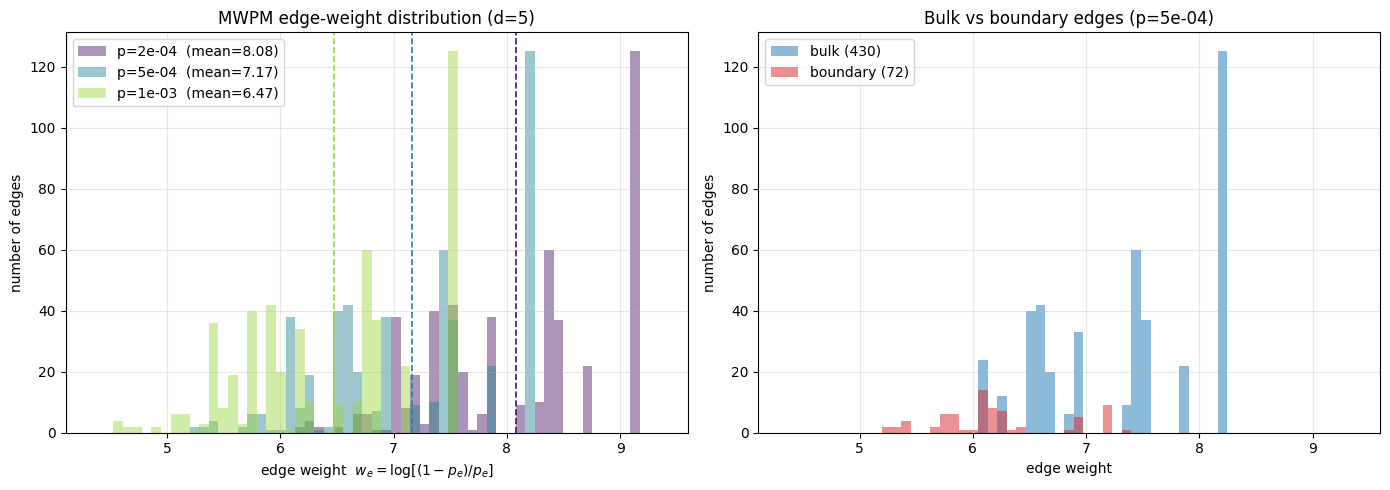

saved plots/mwpm_weight_distribution.png


In [3]:
all_w = np.concatenate([data[p]["w"] for p in CFG["p_values"]])
bins = np.linspace(all_w.min() - 0.2, all_w.max() + 0.2, 60)
colors = plt.cm.viridis(np.linspace(0.05, 0.85, len(CFG["p_values"])))

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for p, c in zip(CFG["p_values"], colors):
    w = data[p]["w"]
    ax[0].hist(w, bins=bins, histtype="stepfilled", alpha=0.45, color=c,
               label=f"p={p:.0e}  (mean={w.mean():.2f})")
    ax[0].axvline(w.mean(), color=c, ls="--", lw=1.2)
ax[0].set_xlabel("edge weight  $w_e = \\log[(1-p_e)/p_e]$")
ax[0].set_ylabel("number of edges"); ax[0].set_title("MWPM edge-weight distribution (d=5)")
ax[0].legend(); ax[0].grid(alpha=0.3)

# Bulk vs boundary edges for the middle p
p_mid = CFG["p_values"][len(CFG["p_values"]) // 2]
d = data[p_mid]
ax[1].hist(d["w"][~d["bnd"]], bins=bins, histtype="stepfilled", alpha=0.5,
           color="#1f77b4", label=f"bulk ({(~d['bnd']).sum()})")
ax[1].hist(d["w"][d["bnd"]], bins=bins, histtype="stepfilled", alpha=0.5,
           color="#d62728", label=f"boundary ({d['bnd'].sum()})")
ax[1].set_xlabel("edge weight"); ax[1].set_ylabel("number of edges")
ax[1].set_title(f"Bulk vs boundary edges (p={p_mid:.0e})")
ax[1].legend(); ax[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig("plots/mwpm_weight_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved plots/mwpm_weight_distribution.png")

## 3. The shift is (almost) a rigid translation

For a single-fault edge $p_e \propto p$, so $w_e \approx -\log p_e$ shifts by $-\log(p'/p)$ when the rate changes. We overlay the histograms *after* subtracting each one's $-\log p$: if every edge scaled linearly in $p$ they would collapse onto one curve. Residual spread = edges that scale differently (e.g. $\sim p^2$ decomposed-hyperedge / correlated mechanisms).

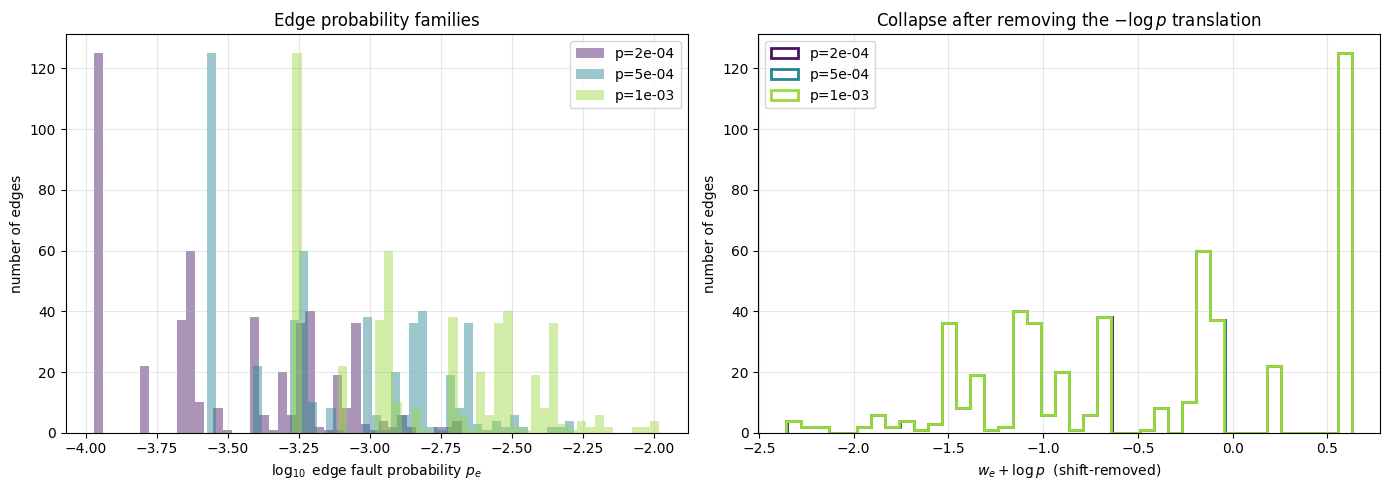

saved plots/mwpm_weight_shift.png


In [4]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# (a) edge fault-probabilities on a log axis -- reveals the p, p^2, ... families
for p, c in zip(CFG["p_values"], colors):
    pr = data[p]["pr"]; pr = pr[np.isfinite(pr) & (pr > 0)]
    ax[0].hist(np.log10(pr), bins=40, histtype="stepfilled", alpha=0.45, color=c,
               label=f"p={p:.0e}")
ax[0].set_xlabel("$\\log_{10}$ edge fault probability $p_e$")
ax[0].set_ylabel("number of edges"); ax[0].set_title("Edge probability families")
ax[0].legend(); ax[0].grid(alpha=0.3)

# (b) weights re-centred by -log(p): collapse test
for p, c in zip(CFG["p_values"], colors):
    w = data[p]["w"] + np.log(p)   # remove the leading -log(p) shift
    ax[1].hist(w, bins=40, histtype="step", lw=2, color=c, label=f"p={p:.0e}")
ax[1].set_xlabel("$w_e + \\log p$  (shift-removed)")
ax[1].set_ylabel("number of edges")
ax[1].set_title("Collapse after removing the $-\\log p$ translation")
ax[1].legend(); ax[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig("plots/mwpm_weight_shift.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved plots/mwpm_weight_shift.png")

In [5]:
# Quantify the mean shift vs the single-fault prediction -log(p'/p)
ref = CFG["p_values"][0]
print(f"reference p = {ref:.0e}, mean weight = {data[ref]['w'].mean():.3f}\n")
print(f"{'p':>8} | {'mean w':>7} | {'measured shift':>14} | {'-log(p/ref)':>12}")
for p in CFG["p_values"]:
    measured = data[p]["w"].mean() - data[ref]["w"].mean()
    predicted = -np.log(p / ref)
    print(f"{p:8.0e} | {data[p]['w'].mean():7.3f} | {measured:14.3f} | {predicted:12.3f}")

reference p = 2e-04, mean weight = 8.083

       p |  mean w | measured shift |  -log(p/ref)
   2e-04 |   8.083 |          0.000 |       -0.000
   5e-04 |   7.166 |         -0.916 |       -0.916
   1e-03 |   6.473 |         -1.610 |       -1.609


## 4. Pairwise correlation weights $w_{\mu\nu}$

For each correlated edge pair $(\mu,\nu)$ in the **line graph**, the DEM gives a **joint fault probability** $p_{\mu\nu}=P(\mu,\nu)$ — this is the `corr_tracer` that correlated matching divides to form the conditional $P(\mu\mid\nu)=p_{\mu\nu}/p_\nu$. Its weight is
$$w_{\mu\nu}=\log\frac{1-p_{\mu\nu}}{p_{\mu\nu}}.$$

We read $p_{\mu\nu}$ straight from `DecodingGraph.from_dem(dem).initial_corr_tracer` (one entry per line-graph edge).

**What to expect:** pairs that **share a physical mechanism** (a $Y$ / hook fault) have $p_{\mu\nu}\sim p$ (small $w_{\mu\nu}$); pairs that co-occur only by **coincidence** have $p_{\mu\nu}\sim p^2$ (larger $w_{\mu\nu}$). So the distribution tends to separate into a shared-mechanism family and a coincidence family, and the gap between them widens as $p\to0$ — this is exactly the low-$p$ correlation contrast that the $\alpha$ reweighting exploits.

In [6]:
from NeuralCM.decoding_graph import DecodingGraph

def joint_corr_weights(p):
    """Return (w_uv, p_uv) for the line-graph joint probabilities p_uv = P(mu, nu) at rate p."""
    gen = SyndromeDataGenerator(
        distance=CFG["distance"], n_rounds=CFG["n_rounds"], mismatch=1.0,
        noise_model={"version": "built-in",
                     "after_clifford_depolarization": p,
                     "before_measure_flip_probability": p,
                     "after_reset_flip_probability": p,
                     "before_round_data_depolarization": p, "p_gate_zz": 0.0},
        memory_type="z", n_shots=1, qec_code="surface_code")
    _, dem, _ = gen.generate_base_circuit()
    g = DecodingGraph.from_dem(dem)
    pmn = np.asarray(g.initial_corr_tracer, dtype=np.float64)   # p_uv = P(mu, nu) per line edge
    pmn = pmn[np.isfinite(pmn) & (pmn > 0) & (pmn < 0.5)]
    return np.log((1.0 - pmn) / pmn), pmn

jdata = {}
for p in CFG["p_values"]:
    w, pmn = joint_corr_weights(p)
    jdata[p] = dict(w=w, pmn=pmn)
    print(f"p={p:.0e} | line-edges={w.size:5d} | w_uv: min={w.min():.2f} mean={w.mean():.2f} max={w.max():.2f} | "
          f"p_uv range=[{pmn.min():.2e}, {pmn.max():.2e}]")

p=2e-04 | line-edges= 1175 | w_uv: min=8.66 mean=10.58 max=11.23 | p_uv range=[1.33e-05, 1.73e-04]
p=5e-04 | line-edges= 1175 | w_uv: min=7.74 mean=9.67 max=10.31 | p_uv range=[3.33e-05, 4.33e-04]
p=1e-03 | line-edges= 1175 | w_uv: min=7.05 mean=8.97 max=9.62 | p_uv range=[6.67e-05, 8.66e-04]


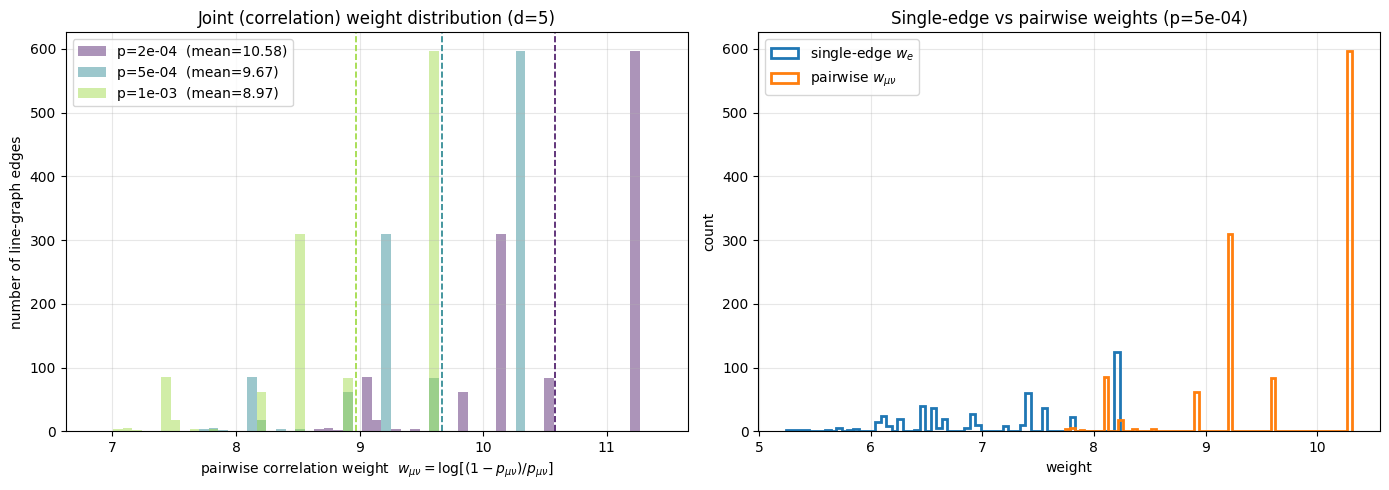

saved plots/mwpm_joint_weight_distribution.png


In [7]:
all_wj = np.concatenate([jdata[p]["w"] for p in CFG["p_values"]])
jbins = np.linspace(all_wj.min() - 0.2, all_wj.max() + 0.2, 60)

fig, ax = plt.subplots(1, 2, figsize=(14, 5))
for p, c in zip(CFG["p_values"], colors):
    w = jdata[p]["w"]
    ax[0].hist(w, bins=jbins, histtype="stepfilled", alpha=0.45, color=c,
               label=f"p={p:.0e}  (mean={w.mean():.2f})")
    ax[0].axvline(w.mean(), color=c, ls="--", lw=1.2)
ax[0].set_xlabel(r"pairwise correlation weight  $w_{\mu\nu}=\log[(1-p_{\mu\nu})/p_{\mu\nu}]$")
ax[0].set_ylabel("number of line-graph edges")
ax[0].set_title("Joint (correlation) weight distribution (d=5)")
ax[0].legend(); ax[0].grid(alpha=0.3)

# single-edge weights vs pairwise weights at the middle p
ax[1].hist(data[p_mid]["w"], bins=60, histtype="step", lw=2, color="#1f77b4", label=r"single-edge $w_e$")
ax[1].hist(jdata[p_mid]["w"], bins=60, histtype="step", lw=2, color="#ff7f0e", label=r"pairwise $w_{\mu\nu}$")
ax[1].set_xlabel("weight"); ax[1].set_ylabel("count")
ax[1].set_title(f"Single-edge vs pairwise weights (p={p_mid:.0e})")
ax[1].legend(); ax[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig("plots/mwpm_joint_weight_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved plots/mwpm_joint_weight_distribution.png")

## 5. Pairwise *conditional* probabilities $P(\mu\mid\nu)$ — are they ~0.5?

Correlated matching's hard reweight uses the **conditional** $P(\mu\mid\nu)=P(\mu,\nu)/P(\nu)=$ `corr_tracer / base_p[nu]`. In the *perfect-measurement* depolarizing case a $Y$ error correlates an X-edge and a Z-edge with the classic value

$$P(\mu\mid\nu)=\frac{p/3}{2p/3}=\tfrac12 \quad\text{(Fowler)}.$$

Does that ½ survive in the full **circuit-level** DEM? We histogram all directed conditionals (both $P(\mu\mid\nu)$ and $P(\nu\mid\mu)$ for each line-graph edge) and check the clustering near 0.5. Since these are ratios of (leading-order $\propto p$) probabilities, they should also be essentially **$p$-independent** — we verify that too.

In [16]:
def conditional_probs(p):
    """All directed pairwise conditionals P(mu|nu) = P(mu,nu)/P(nu) for the correlated pairs."""
    gen = SyndromeDataGenerator(
        distance=CFG["distance"], n_rounds=CFG["n_rounds"], mismatch=1.0,
        noise_model={"version": "built-in",
                     "after_clifford_depolarization": p,
                     "before_measure_flip_probability": p,
                     "after_reset_flip_probability": p,
                     "before_round_data_depolarization": p, "p_gate_zz": 0.0},
        memory_type="z", n_shots=1, qec_code="surface_code")
    _, dem, _ = gen.generate_base_circuit()
    g = DecodingGraph.from_dem(dem)
    line = np.asarray(g.line_edge_index)          # (2, M): decoding-edge index pairs
    corr = np.asarray(g.initial_corr_tracer)      # (M,)  : joint P(mu, nu)
    base = np.asarray(g.base_p)                   # (N,)  : marginal P(edge)
    c = []
    for k in range(line.shape[1]):
        a, b = line[0, k], line[1, k]; j = corr[k]
        if base[b] > 0: c.append(j / base[b])     # P(a | b)
        if base[a] > 0: c.append(j / base[a])     # P(b | a)
    c = np.array(c)
    return np.clip(c[(c > 0) & (c <= 1.0001)], 0, 1)

cdata = {}
for p in CFG["p_values"]:
    c = conditional_probs(p)
    cdata[p] = c
    print(f"p={p:.0e} | n={c.size} | mean={c.mean():.3f} median={np.median(c):.3f} | "
          f"frac near 0.5 [0.45,0.55]={np.mean(np.abs(c - 0.5) < 0.05):.3f} | max={c.max():.3f}")

p=2e-04 | n=2350 | mean=0.100 median=0.065 | frac near 0.5 [0.45,0.55]=0.029 | max=0.500
p=5e-04 | n=2350 | mean=0.100 median=0.065 | frac near 0.5 [0.45,0.55]=0.029 | max=0.500
p=1e-03 | n=2350 | mean=0.100 median=0.065 | frac near 0.5 [0.45,0.55]=0.029 | max=0.500


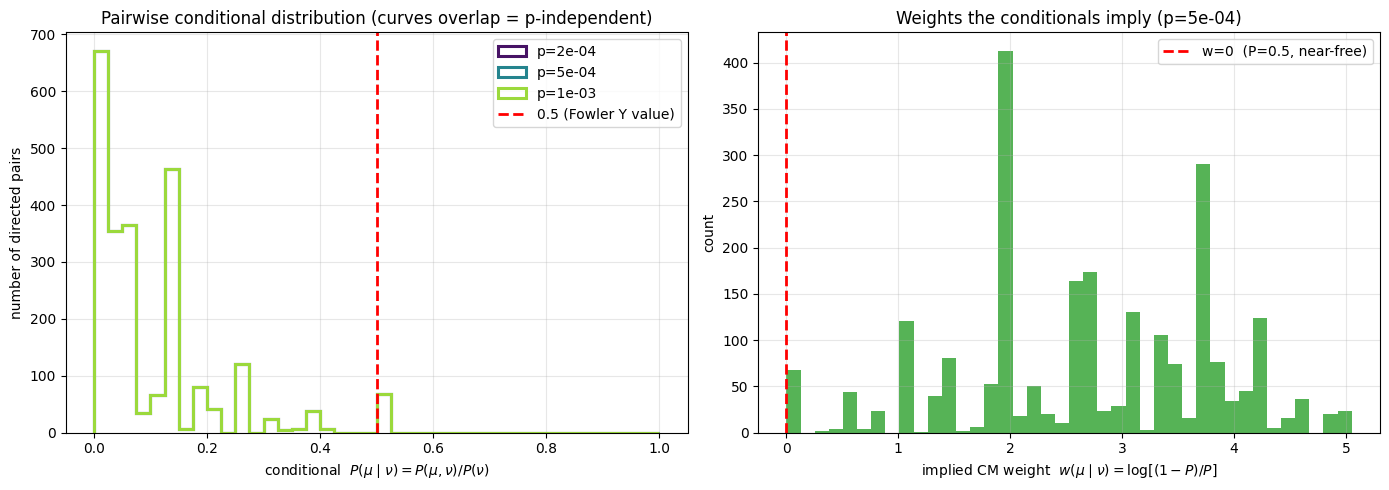

saved plots/mwpm_conditional_distribution.png


In [17]:
fig, ax = plt.subplots(1, 2, figsize=(14, 5))
cb = np.linspace(0, 1, 41)
for p, c in zip(CFG["p_values"], colors):
    ax[0].hist(cdata[p], bins=cb, histtype="step", lw=2.2, color=c, label=f"p={p:.0e}")
ax[0].axvline(0.5, color="red", ls="--", lw=2, label="0.5 (Fowler Y value)")
ax[0].set_xlabel(r"conditional  $P(\mu\mid\nu)=P(\mu,\nu)/P(\nu)$")
ax[0].set_ylabel("number of directed pairs")
ax[0].set_title("Pairwise conditional distribution (curves overlap = p-independent)")
ax[0].legend(); ax[0].grid(alpha=0.3)

# The CM reweight these conditionals imply: w = log((1-P)/P).  P~0.5 -> w~0 (near-free edge).
cclip = np.clip(cdata[p_mid], 1e-6, 0.499999)
w_cond = np.log((1 - cclip) / cclip)
ax[1].hist(w_cond, bins=40, color="#2ca02c", alpha=0.8)
ax[1].axvline(0.0, color="red", ls="--", lw=2, label="w=0  (P=0.5, near-free)")
ax[1].set_xlabel(r"implied CM weight  $w(\mu\mid\nu)=\log[(1-P)/P]$")
ax[1].set_ylabel("count")
ax[1].set_title(f"Weights the conditionals imply (p={p_mid:.0e})")
ax[1].legend(); ax[1].grid(alpha=0.3)
fig.tight_layout()
fig.savefig("plots/mwpm_conditional_distribution.png", dpi=200, bbox_inches="tight")
plt.show()
print("saved plots/mwpm_conditional_distribution.png")

**Finding — the conditionals are *not* clustered at 0.5.**

- The **bulk are small** (median ≈ 0.065): most correlated pairs in the circuit-level DEM are only weakly linked. Only ~3% fall in [0.45, 0.55].
- There **is** a minority near 0.5 — the classic $Y$ / hook shared-mechanism pairs — and **0.5 is effectively the ceiling** (essentially nothing above ~0.6). So the Fowler ½ describes the *strongest* correlations (the upper edge of the distribution), **not** the typical one. The perfect-measurement picture (a $Y$ error splitting cleanly into an X- and Z-edge with conditional ½) is only a small slice of the full circuit-level correlation structure, which adds many weaker hook / gate / measurement correlations.
- **$p$-independent:** the three histograms coincide, because $P(\mu\mid\nu)=P(\mu,\nu)/P(\nu)$ is a ratio of $\propto p$ probabilities — the *correlation structure* doesn't move with $p$ (only the absolute weights do, §1–3).
- **Decoding consequence (right panel):** the ~0.5 pairs imply CM weight $w\approx0$ — **near-free attractor edges**, the over-correction culprits — while the weak-conditional majority get only moderate discounts ($P\approx0.065\Rightarrow w\approx2.7$). This connects the conditional distribution to `docs/pearl_full_posterior_vs_pairwise.md` (why the hard reweight overshoots on the strong pairs).

## Notes / interpretation

- **Same graph, shifted weights.** The single-edge count is identical across $p$; only the weights move. Lower $p$ ⇒ larger weights ⇒ the whole distribution slides to the right.
- **Near-rigid translation.** Most edges are single-fault ($p_e\propto p$), so they translate by $\approx-\log(p'/p)$ — the measured mean shift should track the `-log(p/ref)` column closely. The residual spread in panel 3(b) is the sub-population whose probability scales differently (decomposed-hyperedge / $\sim p^2$ mechanisms), which the boundary/diagonal edges contribute to.
- **Multimodal structure = distinct fault mechanisms.** The peaks correspond to different physical processes (data-qubit depolarization, measurement flips, reset flips, hook errors), each with its own characteristic $p_e$.
- **Pairwise weights $w_{\mu\nu}$ (section 4).** The joint weights are *larger* than single-edge weights because $p_{\mu\nu}\le p_e$. Shared-mechanism pairs ($p_{\mu\nu}\sim p$) sit at lower $w_{\mu\nu}$; coincidence pairs ($p_{\mu\nu}\sim p^2$) at higher $w_{\mu\nu}$, and the separation grows as $p\to0$.
- **Why this matters for decoding.** At lower $p$ the weight *gaps* between edge families grow (in absolute $w$), so the min-weight solution is more sharply determined per syndrome — yet logical failures are dominated by the rare near-degenerate ties where two competing chains have nearly equal total weight. That is exactly the regime where the correlated/Pearl reweighting and the $\alpha$ trust parameter have leverage. See `docs/pearl_vs_bayes_low_p.md`.